In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import os
os.getcwd()

'C:\\Users\\rahem\\Documents\\pittsci\\pmds\\ADDM\\courses\\Case studies\\M5'

In [3]:
trip_2022 = pd.read_csv("POGO-Bike-Share/POGO Bike Share/data/raw/2022c.csv")

In [4]:
trip_2023 = pd.read_csv("POGO-Bike-Share/POGO Bike Share/data/raw/2023c.csv")

In [5]:
trip_2024 = pd.read_csv("POGO-Bike-Share/POGO Bike Share/data/raw/2024c.csv")

In [6]:
trip_2025 = pd.read_csv("POGO-Bike-Share/POGO Bike Share/data/raw/2025c.csv")

In [7]:
# Combine into one dataframe

trips = pd.concat([trip_2022, trip_2023, trip_2024, trip_2025], ignore_index=True)

In [8]:
print("Current folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())


Current folder:
C:\Users\rahem\Documents\pittsci\pmds\ADDM\courses\Case studies\M5

Files in current folder:
['.ipynb_checkpoints', 'Assignment 1_ Business and Data Understanding Report Specifications.pdf', 'Assignment1.Case_Study.pdf', 'POGO-Bike-Share', 'POGO-Bike-Share.zip', 'Rahmatikamel_Fatemeh_Assignment#_Code', 'Untitled.ipynb']


In [9]:
stations = pd.read_csv("POGO-Bike-Share/POGO Bike Share/data/raw/STATION_EXPORT-1222.csv")

## Inspect the Data

In [10]:
trips.head()

,Id,Closed Status,Duration,Start Station Id,Start Date,Start Station Name,End Date,End Station Id,End Station Name,acct ID,Rider Type,Bike Model,Product Name,Rider Id
0,83823,NORMAL,216977,14,12/31/2022 23:39,N Homewood Ave & Finance St,1/3/2023 11:55,32.0,Forbes Ave & Grant St,4805,CASUAL,FIT,Single Ride,NaN
1,83822,NORMAL,2674,24,12/31/2022 23:35,Penn Ave & 33rd St,1/1/2023 0:19,21.0,Liberty Ave & Stanwix St,18031,MEMBER,FIT,Flex Pass,NaN
2,83821,NORMAL,2690,24,12/31/2022 23:34,Penn Ave & 33rd St,1/1/2023 0:19,21.0,Liberty Ave & Stanwix St,1968,MEMBER,FIT,Flex Pass,NaN
3,83820,GRACE_PERIOD,22,24,12/31/2022 23:34,Penn Ave & 33rd St,12/31/2022 23:34,24.0,Penn Ave & 33rd St,18031,MEMBER,FIT,Flex Pass,NaN
4,83819,NORMAL,586,38,12/31/2022 22:59,Allequippa St & Darragh St,12/31/2022 23:09,20.0,Boulevard of the Allies & Parkview Ave,41995,MEMBER,FIT,Annual,NaN


In [11]:
trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 984180 entries, 0 to 984179
Data columns (total 14 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Id                  984180 non-null  int64  
 1   Closed Status       984180 non-null  object 
 2   Duration            984180 non-null  int64  
 3   Start Station Id    984180 non-null  int64  
 4   Start Date          984180 non-null  object 
 5   Start Station Name  984180 non-null  object 
 6   End Date            984180 non-null  object 
 7   End Station Id      983661 non-null  float64
 8   End Station Name    983666 non-null  object 
 9   acct ID             984180 non-null  int64  
 10  Rider Type          984180 non-null  object 
 11  Bike Model          984180 non-null  object 
 12  Product Name        984180 non-null  object 
 13  Rider Id            211251 non-null  float64
dtypes: float64(2), int64(4), object(8)
memory usage: 105.1+ MB


In [12]:
trips.describe()

,Id,Duration,Start Station Id,End Station Id,acct ID,Rider Id
count,9.841800e+05,9.841800e+05,984180.000000,983661.000000,984180.000000,211251.000000
mean,5.447509e+05,1.002712e+03,26.813828,26.625071,26612.131390,26608.107758
std,3.103816e+05,5.198783e+03,14.859516,14.903074,15367.262032,13972.447985
min,1.100000e+02,0.000000e+00,1.000000,1.000000,1.000000,2.000000
25%,2.757158e+05,2.410000e+02,13.000000,13.000000,12988.000000,16416.000000
50%,5.474915e+05,4.300000e+02,26.000000,25.000000,26757.000000,26668.000000
75%,8.115652e+05,9.340000e+02,37.000000,37.000000,39953.000000,39783.000000
max,1.080806e+06,1.969581e+06,62.000000,62.000000,52747.000000,49563.000000


In [13]:
trips.columns

Index(['Id', 'Closed Status', 'Duration', 'Start Station Id', 'Start Date',
       'Start Station Name', 'End Date', 'End Station Id', 'End Station Name',
       'acct ID', 'Rider Type', 'Bike Model', 'Product Name', 'Rider Id'],
      dtype='object')

## Clean the Data

In [14]:
trips['Duration'].head()

0    216977
1      2674
2      2690
3        22
4       586
Name: Duration, dtype: int64

This numbers are far too large to be minutes, I think That means Duration is almost certainly in seconds.

also:
216977 / 60 ≈ 3616 minutes ≈ 60 hours
That is not a normal bike trip.

I should filter unrealistic durations.

In [18]:
# Keep trips between 1 minute and 4 hours

trips = trips[
    (trips['trip_duration_minutes'] >= 1) &
    (trips['trip_duration_minutes'] <= 240)
]

In [19]:
# Create Time Features

trips['Start Date'] = pd.to_datetime(trips['Start Date'])

trips['year'] = trips['Start Date'].dt.year
trips['month'] = trips['Start Date'].dt.month
trips['hour'] = trips['Start Date'].dt.hour
trips['day_of_week'] = trips['Start Date'].dt.day_name()


## Analysis

In [20]:
# Trips by Year

trips.groupby('year').size()

year
2022     64446
2023    197618
2024    440629
2025    228747
dtype: int64

2025 is like Descent data.
i want to compute growth rates:

In [21]:
yearly_counts = trips.groupby('year').size()

growth_rate = yearly_counts.pct_change() * 100
growth_rate

year
2022           NaN
2023    206.641219
2024    122.970074
2025    -48.086259
dtype: float64

In [22]:
trips['Start Date'].max()

Timestamp('2025-07-31 23:57:00')

In [23]:
trips[trips['year'] == 2025]['month'].unique()

array([7, 6, 5, 4, 3, 2, 1])

That means we only have January–May.

In [24]:
trips[trips['year'] == 2025].groupby('month').size()

month
1    15299
2    22633
3    34580
4    46666
5    32250
6    35617
7    41702
dtype: int64

Now I know: 2025 Is Misleading

That -48% decline is almost certainly because 2025 is partial-year data, so we can't compare a partial year to a full year.

From 2022 → 2024:

Explosive adoption

Over 200% growth in 2023
Over 120% growth in 2024

In [25]:
# Trips by Rider Type

trips['Rider Type'].value_counts()

Rider Type
MEMBER    828954
CASUAL    102486
Name: count, dtype: int64

<Axes: xlabel='hour'>

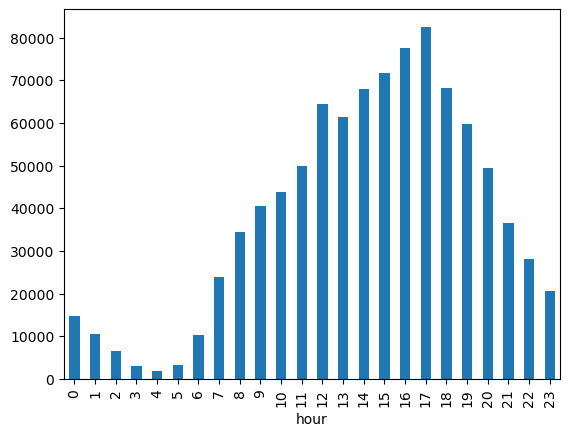

In [26]:
# Trips by Hour

trips.groupby('hour').size().plot(kind='bar')

This Chart Shows us:

Very low activity between 2–5 AM.
Trips increase starting around 6–7 AM.
Strong rise through late morning and afternoon.
Peak around 4–5 PM.
Gradual decline after 7 PM.

In [27]:
# Top 10 Start Stations

trips['Start Station Name'].value_counts().head(10)

Start Station Name
S Bouquet Ave & Sennott St                83696
Boulevard of the Allies & Parkview Ave    62072
Atwood St & Bates St                      51552
N Dithridge St & Centre Ave               49374
Forbes Ave & Schenley Dr                  40987
Zulema St & Coltart Ave                   40239
O'Hara St and University Place            37877
Fifth Ave & S Bouquet St                  37585
Coltart Ave & Forbes Ave                  32730
Allequippa St & Darragh St                31545
Name: count, dtype: int64

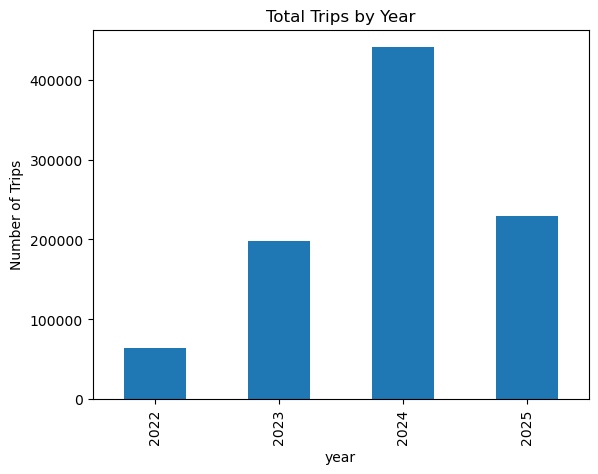

In [30]:
yearly_counts.plot(kind='bar')
plt.title("Total Trips by Year")
plt.ylabel("Number of Trips")
plt.show()

This bar chart tells us:

2022 → low number of trips

2023 → big increase compared to 2022

2024 → highest year (strong growth)

2025 → lower than 2024

The drop in 2025 likely does not mean demand fell (Earlier we identified that 2025 is a partial year (data does not include all 12 months), So it is naturally lower.

If we compare only full years:
2022 → 2023 → 2024 shows strong upward growth.

That means:
System adoption increased
Ridership expanded
Operational demand increased each year

## Compare:

### Member vs Casual Behavior by Hour

<Axes: xlabel='hour'>

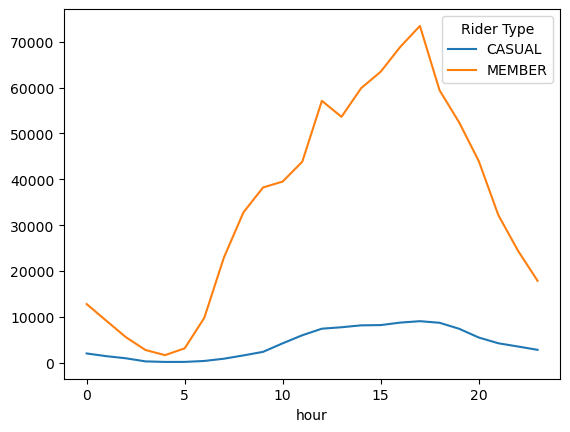

In [31]:
trips.groupby(['hour', 'Rider Type']).size().unstack().plot()

This chart shows how many bike trips happen each hour of the day, separated by rider type (Member vs Casual).

1) Members (Orange Line):
Very low usage overnight (2–5 AM).
Usage starts increasing around 6–7 AM.
Strong peak between 4–6 PM.
Drops again after 7 PM.

Members are likely using bikes to go to work and come home.

2) Casual Riders (Blue Line)
Lower overall numbers.
Usage increases gradually through the morning.
Peaks in the late afternoon.
Also low overnight.

More steady throughout the day compared to Members.

### Member vs Casual by Day of Week

<Axes: xlabel='day_of_week'>

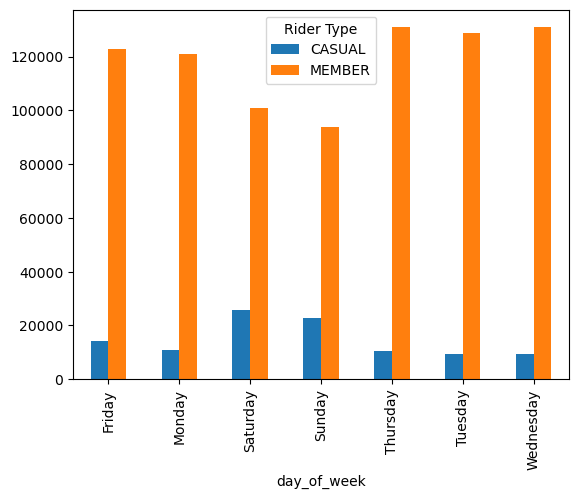

In [32]:
trips.groupby(['day_of_week', 'Rider Type']).size().unstack().plot(kind='bar')

From This Chart I found: 
1) Members dominate every day( That confirms a subscription-heavy system).

2) Casual riders increase sharply on weekends (Saturday and Sunday are visibly higher for Casual).

3)  Members are strong on weekdays (Thursday, Tuesday, Wednesday are very high).

So:
Members = transportation utility users
Casual = leisure/weekend riders

In [33]:
station_counts = trips['Start Station Name'].value_counts()

num_stations = station_counts.count()
num_stations

78

Total number of active stations in your dataset.

In [34]:
station_counts.head

<bound method NDFrame.head of Start Station Name
S Bouquet Ave & Sennott St                83696
Boulevard of the Allies & Parkview Ave    62072
Atwood St & Bates St                      51552
N Dithridge St & Centre Ave               49374
Forbes Ave & Schenley Dr                  40987
                                          ...  
Burns white at 3 crossings                    5
Parkview & Blvd of the Allies                 3
Penn Ave & S Whitfield                        3
Test-STATION                                  1
TestLucOffice                                 1
Name: count, Length: 78, dtype: int64>

How much load does each station carry?

Load = number of trips starting from that station.
That shows busiest stations.

In [35]:
station_percent = station_counts / station_counts.sum() * 100

station_percent.head

<bound method NDFrame.head of Start Station Name
S Bouquet Ave & Sennott St                8.985657
Boulevard of the Allies & Parkview Ave    6.664090
Atwood St & Bates St                      5.534656
N Dithridge St & Centre Ave               5.300825
Forbes Ave & Schenley Dr                  4.400391
                                            ...   
Burns white at 3 crossings                0.000537
Parkview & Blvd of the Allies             0.000322
Penn Ave & S Whitfield                    0.000322
Test-STATION                              0.000107
TestLucOffice                             0.000107
Name: count, Length: 78, dtype: float64>

Some stations are extremely busy.
Many stations are much lighter.

In [36]:
average_load = len(trips) / num_stations
average_load

11941.538461538461

Average trips per station ≈ 11,941

In [37]:
station_counts.max()

83696

Maximum trips at busiest station = 83,691

Now I can compare them:

83,691 ÷ 11,941 ≈ 7

That means The busiest station handles about 7 times more trips than the average station.

In [38]:
top_10_share = (
    trips['Start Station Name']
    .value_counts()
    .head(10)
    .sum()
) / len(trips)

top_10_share * 100


50.20795757107275

Top 10 stations = about 50% of all trips.
Out of all stations in the system, just 10 stations are responsible for half of all bike trips.


Why does this matter?

If 10 stations handle half the trips:
They need more bikes.
They need more maintenance.
They need more rebalancing.
They are under more operational pressure.

## Save outputs

In [39]:
os.makedirs("outputs", exist_ok=True)

In [40]:
yearly_counts.to_csv("outputs/trips_by_year.csv")

rider_counts = trips['Rider Type'].value_counts(normalize=True) * 100
rider_counts.to_csv("outputs/rider_type_percentages.csv")

top_10_share = (trips['Start Station Name'].value_counts().head(10).sum()) / len(trips)

pd.DataFrame({"top_10_share_percent":[top_10_share*100]}).to_csv("outputs/top10_station_share.csv", index=False)

In [41]:
with open("README.md", "w") as f:
    f.write("# Assignment 1 – POGOH Bike Share Analysis\n")